# Exploratory Data Analysis

## import libraries

In [121]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

import statsmodels.api as sm

import holidays
import datetime as dt

import requests

## define functions

In [176]:
def get_season(month):
    if month in [12, 1, 2]:
        return 1 # , "winter"
    elif month in [3, 4, 5]:
        return 2 # , "spring"
    elif month in [6, 7, 8]:
        return 3 # , "summer"
    else:
        return 4 # , "autumn"
    
def encode_cyclic(df, col, max_val, offset=0):
    df[f"{col}_sin"] = np.sin(2 * np.pi * (df[col] + offset) / max_val)
    df[f"{col}_cos"] = np.cos(2 * np.pi * (df[col] + offset) / max_val)
    return df

def load_openmeteo_weather(lat=50.15, lon=6.33,
                           start="2023-01-01", end="2026-01-01",
                           tz="Europe/Berlin"):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "hourly": ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "wind_speed_10m",
            "shortwave_radiation",
            "precipitation",
            "cloud_cover"
        ]),
        "timezone": tz
    }

    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()

    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")

    return df

def wet_bulb_temperature(T, RH):
    """
    T in °C, RH in %
    Stull formula (2011) – very accurate for practical use.
    """
    Tw = (T * np.arctan(0.151977 * np.sqrt(RH + 8.313659)) +
          np.arctan(T + RH) - np.arctan(RH - 1.676331) +
          0.00391838 * (RH ** 1.5) * np.arctan(0.023101 * RH) -
          4.686035)

    return round(Tw, 2)


def heating_degree_day(temp_mean, base=18):
    return round(max(0, base - temp_mean), 2)


def cooling_degree_day(temp_mean, base=22):
    return round(max(0, temp_mean - base), 2)

def add_features(df):

    # we have 4 values for each hour -> value 2 hours -> shift by 4 values multiplied by 2 hours
    df["load_15min_ago"] = df["load_15min"].shift(1*1)
    df["load_30min_ago"] = df["load_15min"].shift(1*2)
    df["load_1h_ago"] = df["load_15min"].shift(1*4)
    df["load_2h_ago"] = df["load_15min"].shift(2*4)
    df["load_4h_ago"] = df["load_15min"].shift(4*4)
    df["load_6h_ago"] = df["load_15min"].shift(6*4)
    df["load_12h_ago"] = df["load_15min"].shift(12*4)
    df["load_24h_ago"] = df["load_15min"].shift(24*4)
    df["load_168h_ago"] = df["load_15min"].shift(168*4)

    # we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
    df["rolling_mean_1h"] = df["load_15min"].rolling(window=1*4).mean()
    df["rolling_mean_3h"] = df["load_15min"].rolling(window=3*4).mean()
    df["rolling_mean_4h"] = df["load_15min"].rolling(window=4*4).mean()
    df["rolling_mean_6h"] = df["load_15min"].rolling(window=6*4).mean()
    df["rolling_mean_12h"] = df["load_15min"].rolling(window=12*4).mean()
    df["rolling_mean_24h"] = df["load_15min"].rolling(window=24*4).mean()

    # we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
    df["rolling_std_3h"] = df["load_15min"].rolling(window=3*4).std()
    df["rolling_std_6h"] = df["load_15min"].rolling(window=6*4).std()
    df["rolling_std_12h"] = df["load_15min"].rolling(window=12*4).std()
    df.head(12)

    # Beispiel: 15min-Daten → Lags und rolling in Stunden & Tagen
    for col in ["temp","wet_bulb","radiation", "precip", "rel_humidity","wind","clouds"]:
        for steps in [1, 3, 6, 24, 48]:              # 1h, 3h, 6h, 1d, 2d
            df[f"{col}_lag{steps}h"] = df[col].shift(steps*4)
        for steps_2 in [3, 6, 12]:                    # 3h, 6h, 12h
            df[f"rolling_{col}_{steps_2}h"]  = df[col].rolling(steps_2*4, min_periods=1).mean()

    return df


## 1. - load datasets

### 1.1 - electrical load

In [124]:
df_load_15min = pd.read_csv(r"dataset\raw-data\load_data_2024-01-01_2026-02-28_UTC.csv", header=None, names=["date_time","load_15min"] )
df_load_15min = df_load_15min[2:]                       # delete first two rows (old headers)
df_load_15min["date_time"] = pd.to_datetime(df_load_15min["date_time"])
df_load_15min = df_load_15min.set_index("date_time")    # set column date_time as index
df_load_15min = df_load_15min.sort_index()              # sort by index (timestamp)
df_load_15min.head(-5)

,load_15min
date_time,
2024-01-01 00:00:00,9.13 MW
2024-01-01 00:15:00,9.05 MW
2024-01-01 00:30:00,8.96 MW
2024-01-01 00:45:00,8.95 MW
2024-01-01 01:00:00,8.61 MW
...,...
2026-02-28 21:30:00,11.62 MW
2026-02-28 21:45:00,11.43 MW
2026-02-28 22:00:00,11.26 MW


### 1.2 - weather data

#### 1.2.1 - historical weather data

In [125]:
# load weather data
start = df_load_15min.index.min().date().isoformat()   # get the oldest date in this format -> "YYYY-MM-DD"
end = df_load_15min.index.max().date().isoformat()     # get the youngest date in this format -> "YYYY-MM-DD"

print(f"start date: {start}, end date: {end}")
df_weather_hourly = load_openmeteo_weather(lat=50.3,        # latitude for 54597 Pronsfeld, Germany
                                        lon=6.42,           # longitude for 54597 Pronsfeld, Germany
                                        start=start,        # define start date based on oldest date in load dataset -> or "YYYY-MM-DD"
                                        end=end,            # define end date based on youngest date in load dataset -> or "YYYY-MM-DD"
                                        tz="UTC")           # "Europe/Berlin" -> UTC better for forecasting

# resample to 15-min resolution -> electrical load has the same resolution
df_weather_15min = df_weather_hourly.resample("15min").interpolate()

# renaming columns
df_weather_15min = df_weather_15min.rename(columns={
    "temperature_2m": "temp",
    "relative_humidity_2m": "rel_humidity",
    "wind_speed_10m": "wind",
    "shortwave_radiation": "radiation",
    "precipitation": "precip",
    "cloud_cover": "clouds"
})

df_weather_15min.head()

start date: 2024-01-01, end date: 2026-02-28


,temp,rel_humidity,wind,radiation,precip,clouds
time,,,,,,
2024-01-01 00:00:00,3.5,94.00,31.40,0.0,0.000,100.0
2024-01-01 00:15:00,3.5,93.75,31.65,0.0,0.025,94.5
2024-01-01 00:30:00,3.5,93.50,31.90,0.0,0.050,89.0
2024-01-01 00:45:00,3.5,93.25,32.15,0.0,0.075,83.5
2024-01-01 01:00:00,3.5,93.00,32.40,0.0,0.100,78.0


### 1.3 - merge datasets (electrical load and weather data)

In [126]:
df_load_and_weather = df_load_15min.join(df_weather_15min, how="left")
df_load_and_weather.head()



,load_15min,temp,rel_humidity,wind,radiation,precip,clouds
date_time,,,,,,,
2024-01-01 00:00:00,9.13 MW,3.5,94.00,31.40,0.0,0.000,100.0
2024-01-01 00:15:00,9.05 MW,3.5,93.75,31.65,0.0,0.025,94.5
2024-01-01 00:30:00,8.96 MW,3.5,93.50,31.90,0.0,0.050,89.0
2024-01-01 00:45:00,8.95 MW,3.5,93.25,32.15,0.0,0.075,83.5
2024-01-01 01:00:00,8.61 MW,3.5,93.00,32.40,0.0,0.100,78.0


## 2. - explore the data

### 2.1 - check the data types of the dataset

In [127]:
df_load_and_weather.dtypes

load_15min          str
temp            float64
rel_humidity    float64
wind            float64
radiation       float64
precip          float64
clouds          float64
dtype: object

### 2.2 - checking the count of missing values per column

In [128]:
df_load_and_weather.isna().sum()

load_15min      134
temp              3
rel_humidity      3
wind              3
radiation         3
precip            3
clouds            3
dtype: int64

### 2.3 - check for missing timestamps

In [129]:
# expect exactly one value every 15 min from first to last timestamp
expected = pd.date_range(df_load_and_weather.index.min(), df_load_and_weather.index.max(), freq="15min")

# collect missing timestamps -> available in "expected", but not in the DataFrame
missing = expected.difference(df_load_and_weather.index)

print(f"count of missing 15 min timestamps: {len(missing)}")
display(pd.DataFrame(missing[:20],columns=["missing timestamps"]))  # show first 20 missing timestamps


count of missing 15 min timestamps: 0


,missing timestamps


**missing timestamps always during the change from winter to summer time**
- 2 a.m. -> 3 a.m.

**but we choose UTC as timeformat, so we don't have this problem**

### 2.4 - check for duplicated timestamps

In [130]:
# expect exactly one value every 15 min from first to last timestamp -> store duplicates
duplicates = df_load_and_weather.index[df_load_and_weather.index.duplicated()].rename(None)

print(f"count of duplicated 15 min timestamps: {len(duplicates)}")
display(pd.DataFrame(duplicates[:20],columns=["duplicated timestamps"]))  # show first 20 duplicated timestamps

count of duplicated 15 min timestamps: 0


,duplicated timestamps


**duplicated timestamps always during the change from summer to winter time**
- 3 a.m. -> 2 a.m.

**but we choose UTC as timeformat, so we don't have this problem**

## 3. - data cleaning

### 3.1 - handle duplicate timestamps
- delete timestamp duplicates
    - only if there are duplicate timestamps




In [131]:
df_load_and_weather = df_load_and_weather[~df_load_and_weather.index.duplicated(keep="first")]    # delete duplicated rows

#check for duplicates again
duplicates = df_load_and_weather.index[df_load_and_weather.index.duplicated()].rename(None)

print(f"count of duplicated 15 min timestamps: {len(duplicates)}")
display(pd.DataFrame(duplicates[:20],columns=["duplicated timestamps"]))  # show first 20 duplicated timestamps

count of duplicated 15 min timestamps: 0


,duplicated timestamps


### 3.2 - handle dtypes
- change load value from string to int

In [132]:
df_load_and_weather.head()

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds
date_time,,,,,,,
2024-01-01 00:00:00,9.13 MW,3.5,94.00,31.40,0.0,0.000,100.0
2024-01-01 00:15:00,9.05 MW,3.5,93.75,31.65,0.0,0.025,94.5
2024-01-01 00:30:00,8.96 MW,3.5,93.50,31.90,0.0,0.050,89.0
2024-01-01 00:45:00,8.95 MW,3.5,93.25,32.15,0.0,0.075,83.5
2024-01-01 01:00:00,8.61 MW,3.5,93.00,32.40,0.0,0.100,78.0


In [133]:
col = "load_15min"          # set column name
 
# calculate new column
df_load_and_weather[col] = (
    pd.to_numeric(
        df_load_and_weather[col]
            .astype(str)                              # make sure that all values are strings
            .str.replace(",", ".", regex=False)       # if it exists, replace decimal separator ("," with ".")
            .str.extract(r"([-+]?\d*\.?\d+)")[0],     # extract only the first number out of the string
        errors="coerce"
    )
    .mul(1000)          # change unit (MW to kW)
    .round()            # avoid rounding error by multiplying in the previous row
    .astype("Int64")    # int64 because i don't want an error for the NaN values
)

df_load_and_weather.head()

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds
date_time,,,,,,,
2024-01-01 00:00:00,9130,3.5,94.00,31.40,0.0,0.000,100.0
2024-01-01 00:15:00,9050,3.5,93.75,31.65,0.0,0.025,94.5
2024-01-01 00:30:00,8960,3.5,93.50,31.90,0.0,0.050,89.0
2024-01-01 00:45:00,8950,3.5,93.25,32.15,0.0,0.075,83.5
2024-01-01 01:00:00,8610,3.5,93.00,32.40,0.0,0.100,78.0


### 3.3 - handle outliers

**being an expert in the field, i can say:**
- The values in the lower range are not outliers!
    - Most of these are caused by lower production capacity utilization, and some extreme cases can be attributed to power outages.
- The values in the upper range are all outliers!
    - All were recorded due to errors in the measuring equipment. It is not possible to draw such a high electrical load at the site.
        - Delete all and fill the gap linearly between the last and next existing value.

#### 3.3.1 - create boxplot

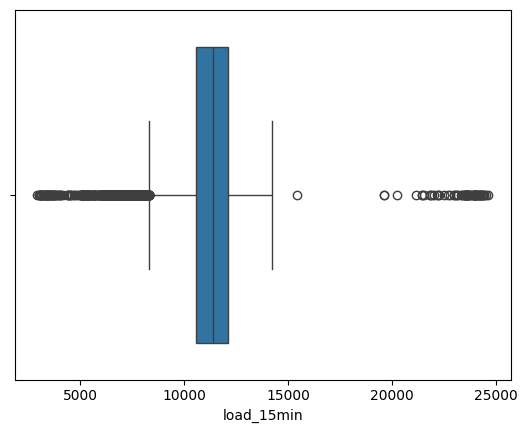

In [134]:
col = "load_15min"

sns.boxplot(x=col, data = df_load_and_weather)                            
plt.show()

#### 3.3.1 - find min load value

In [135]:
col = "load_15min"

# 1) Minimum value and timestamp of minimum value
min_val = df_load_and_weather[col].min()
min_ts  = df_load_and_weather[col].idxmin()

# 2) Position (Integer-Index) of the timestamp
loc = df_load_and_weather.index.get_loc(min_ts)

# 3) create window ±10 values regarding the minimum value timestamp
window = df_load_and_weather.iloc[max(loc-10, 0):loc+11]

# 4) define color highlighting

def highlight_min_row(s):
    return [
        "background-color: yellow; color: black;" if idx == min_ts else ""
        for idx in s.index
    ]

# 5) output
print(f"Min load value: {min_val} kW")
print(f"Min load timestamp: {min_ts}\n")

display(window.style.apply(highlight_min_row, axis=0))

Min load value: 2930 kW
Min load timestamp: 2024-06-19 06:45:00



,load_15min,temp,rel_humidity,wind,radiation,precip,clouds
date_time,,,,,,,
2024-06-19 04:15:00,5010,12.125000,99.750000,15.550000,7.250000,0.000000,100.000000
2024-06-19 04:30:00,4990,12.150000,99.500000,15.700000,11.500000,0.000000,100.000000
2024-06-19 04:45:00,5060,12.175000,99.250000,15.850000,15.750000,0.000000,100.000000
2024-06-19 05:00:00,4680,12.200000,99.000000,16.000000,20.000000,0.000000,100.000000
2024-06-19 05:15:00,4550,12.200000,99.000000,15.825000,23.500000,0.000000,100.000000
2024-06-19 05:30:00,4340,12.200000,99.000000,15.650000,27.000000,0.000000,100.000000
2024-06-19 05:45:00,3730,12.200000,99.000000,15.475000,30.500000,0.000000,100.000000
2024-06-19 06:00:00,3110,12.200000,99.000000,15.300000,34.000000,0.000000,100.000000
2024-06-19 06:15:00,3030,12.375000,98.000000,15.900000,58.500000,0.025000,100.000000


#### 3.3.2 - find max load value

In [136]:
col = "load_15min"

# 1) Minimum value and timestamp of minimum value
min_val = df_load_and_weather[col].max()
min_ts  = df_load_and_weather[col].idxmax()

# 2) Position (Integer-Index) of the timestamp
loc = df_load_and_weather.index.get_loc(min_ts)

# 3) create window ±10 values regarding the minimum value timestamp
window = df_load_and_weather.iloc[max(loc-10, 0):loc+11]

# 4) define color highlighting
def highlight_min_row(s):
    return [
        "background-color: yellow; color: black;" if idx == min_ts else ""
        for idx in s.index
    ]

# 5) output
print(f"Max load value: {min_val} kW")
print(f"Max load timestamp: {min_ts}\n")

display(window.style.apply(highlight_min_row, axis=0))

Max load value: 24650 kW
Max load timestamp: 2025-12-17 06:00:00



,load_15min,temp,rel_humidity,wind,radiation,precip,clouds
date_time,,,,,,,
2025-12-17 03:30:00,23650,1.750000,96.000000,11.250000,0.000000,0.000000,0.000000
2025-12-17 03:45:00,24240,1.625000,96.500000,11.325000,0.000000,0.000000,0.000000
2025-12-17 04:00:00,24230,1.500000,97.000000,11.400000,0.000000,0.000000,0.000000
2025-12-17 04:15:00,23840,1.500000,97.250000,11.600000,0.000000,0.000000,0.000000
2025-12-17 04:30:00,23980,1.500000,97.500000,11.800000,0.000000,0.000000,0.000000
2025-12-17 04:45:00,23960,1.500000,97.750000,12.000000,0.000000,0.000000,0.000000
2025-12-17 05:00:00,23670,1.500000,98.000000,12.200000,0.000000,0.000000,0.000000
2025-12-17 05:15:00,23550,1.575000,98.000000,12.050000,0.000000,0.000000,0.750000
2025-12-17 05:30:00,23730,1.650000,98.000000,11.900000,0.000000,0.000000,1.500000


#### 3.3.3 - delete load outliers
- Delete all outliers only at the upper limit (> 15MW)

In [137]:
df_load_and_weather.isna().sum()

load_15min      134
temp              3
rel_humidity      3
wind              3
radiation         3
precip            3
clouds            3
dtype: int64

In [138]:
df_clean = df_load_and_weather.copy()

#############################################
# delete outliers > 15000 (→ NaN)
#############################################
df_clean.loc[df_clean["load_15min"] > 15000, "load_15min"] = pd.NA

In [139]:
df_clean.isna().sum()

load_15min      206
temp              3
rel_humidity      3
wind              3
radiation         3
precip            3
clouds            3
dtype: int64

Max load value: 14230 kW
Max load timestamp: 2026-02-16 11:30:00



,load_15min,temp,rel_humidity,wind,radiation,precip,clouds
date_time,,,,,,,
2026-02-16 09:00:00,12380,1.500000,97.000000,17.300000,70.000000,0.000000,100.000000
2026-02-16 09:15:00,12420,1.600000,96.500000,17.500000,95.000000,0.000000,100.000000
2026-02-16 09:30:00,12650,1.700000,96.000000,17.700000,120.000000,0.000000,100.000000
2026-02-16 09:45:00,13110,1.800000,95.500000,17.900000,145.000000,0.000000,100.000000
2026-02-16 10:00:00,13060,1.900000,95.000000,18.100000,170.000000,0.000000,100.000000
2026-02-16 10:15:00,12750,1.775000,95.500000,17.025000,171.000000,0.600000,100.000000
2026-02-16 10:30:00,12600,1.650000,96.000000,15.950000,172.000000,1.200000,100.000000
2026-02-16 10:45:00,12700,1.525000,96.500000,14.875000,173.000000,1.800000,100.000000
2026-02-16 11:00:00,12900,1.400000,97.000000,13.800000,174.000000,2.400000,100.000000


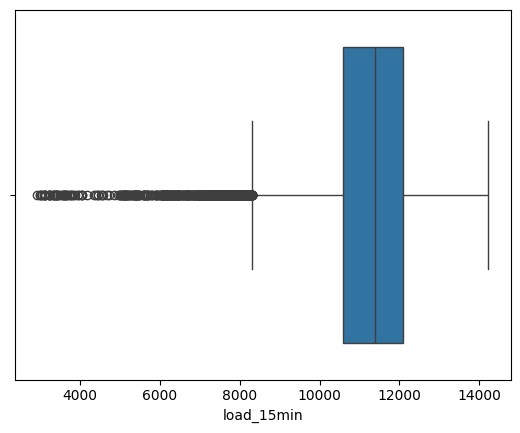

In [140]:
# checking for the highest value again after deleting the outliers

col = "load_15min"

# 1) Minimum value and timestamp of minimum value
min_val = df_clean[col].max()
min_ts  = df_clean[col].idxmax()

# 2) Position (Integer-Index) of the timestamp
loc = df_clean.index.get_loc(min_ts)

# 3) create window ±10 values regarding the minimum value timestamp
window = df_clean.iloc[max(loc-10, 0):loc+11]

# 4) define color highlighting
def highlight_min_row(s):
    return [
        "background-color: yellow; color: black;" if idx == min_ts else ""
        for idx in s.index
    ]

# 5) output
print(f"Max load value: {min_val} kW")
print(f"Max load timestamp: {min_ts}\n")

display(window.style.apply(highlight_min_row, axis=0))

sns.boxplot(x=col, data = df_clean)                            
plt.show()

### 3.4 - handle missing values
- fill the gaps linearly between the last and next existing value.

In [141]:
# check count of NaN values before filling the gaps
print(df_clean.isna().sum())

load_15min      206
temp              3
rel_humidity      3
wind              3
radiation         3
precip            3
clouds            3
dtype: int64


In [142]:
print(df_clean.dtypes)

load_15min        Int64
temp            float64
rel_humidity    float64
wind            float64
radiation       float64
precip          float64
clouds          float64
dtype: object


In [143]:
#############################################
# fill gaps linear 
#############################################
df_clean = (
    df_clean
        .interpolate(method="time", limit_direction="both")   # fill in both directions to fill the beginning and end to
)

df_clean["load_15min"] = (
    df_clean["load_15min"]
        .round()
        .astype("Int64")              # change float + NaN → Int64 + <NA>
)



In [144]:
print(df_clean.dtypes)

load_15min        Int64
temp            float64
rel_humidity    float64
wind            float64
radiation       float64
precip          float64
clouds          float64
dtype: object


In [145]:
# check count of NaN values after filling the gaps
print(df_clean.isna().sum())

load_15min      0
temp            0
rel_humidity    0
wind            0
radiation       0
precip          0
clouds          0
dtype: int64


## 4. - visualize some data

### 4.1 - outliers - before and after cleaning

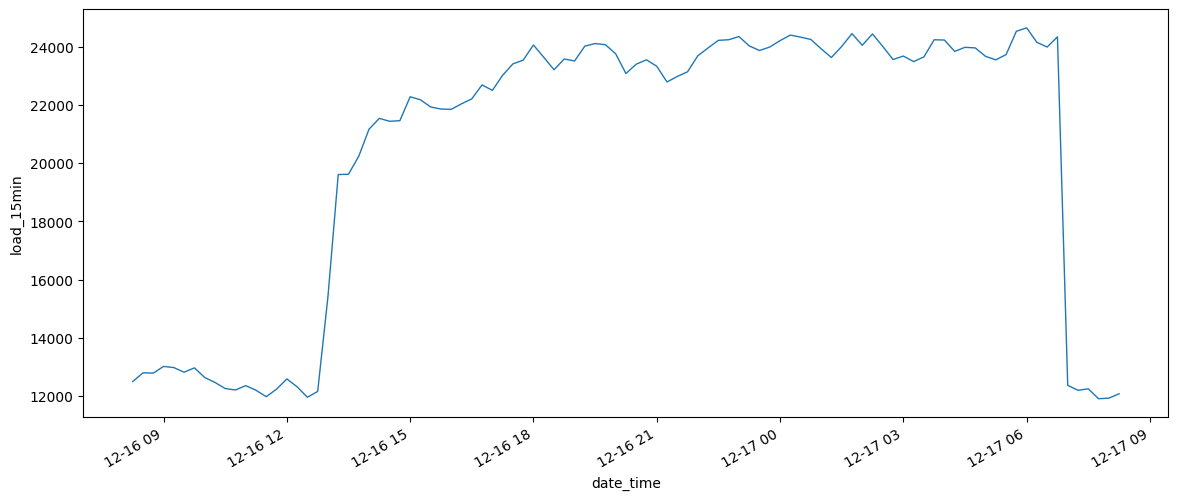

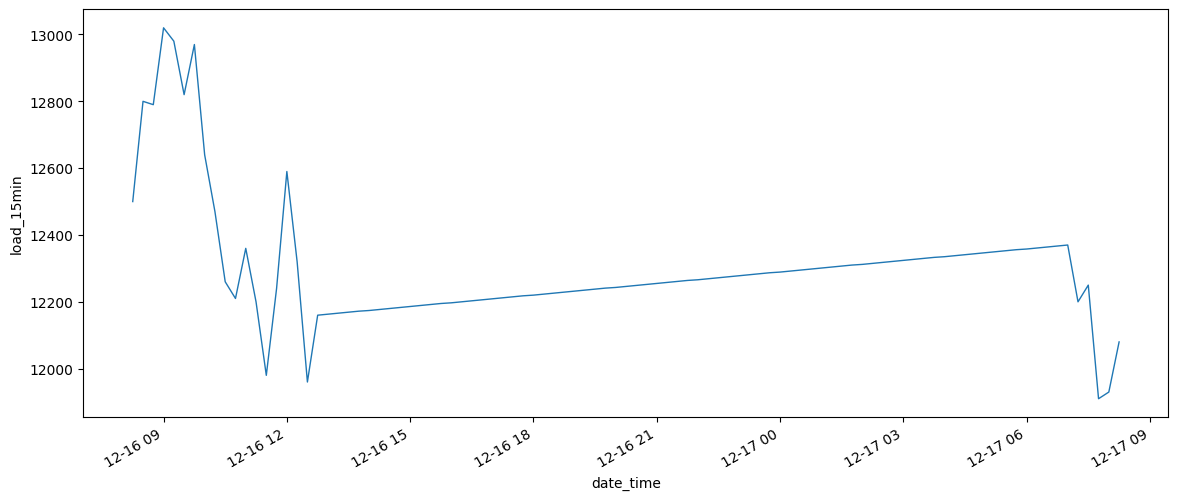

In [146]:
start_date = "2025-12-16 08:15:00	"     # only year "2024" -> a specific month "2024-1" -> a specific day "2024-1-30"
end_date = "2025-12-17 08:15:00	"

# select time period
df_plot = df_load_and_weather.loc[start_date:end_date]

plt.figure(figsize=(14,6))
sns.lineplot(data=df_plot,
             x="date_time",
             y="load_15min",
             linewidth=1.0
             )

plt.gcf().autofmt_xdate()       # automatically format and rotate the date
plt.show()

df_plot = df_clean.loc[start_date:end_date]

plt.figure(figsize=(14,6))
sns.lineplot(data=df_plot,
             x="date_time",
             y="load_15min",
             linewidth=1.0
             )

plt.gcf().autofmt_xdate()       # automatically format and rotate the date
plt.show()

### 4.2 - including a line for the daily, monthly, yearly average to see the trend

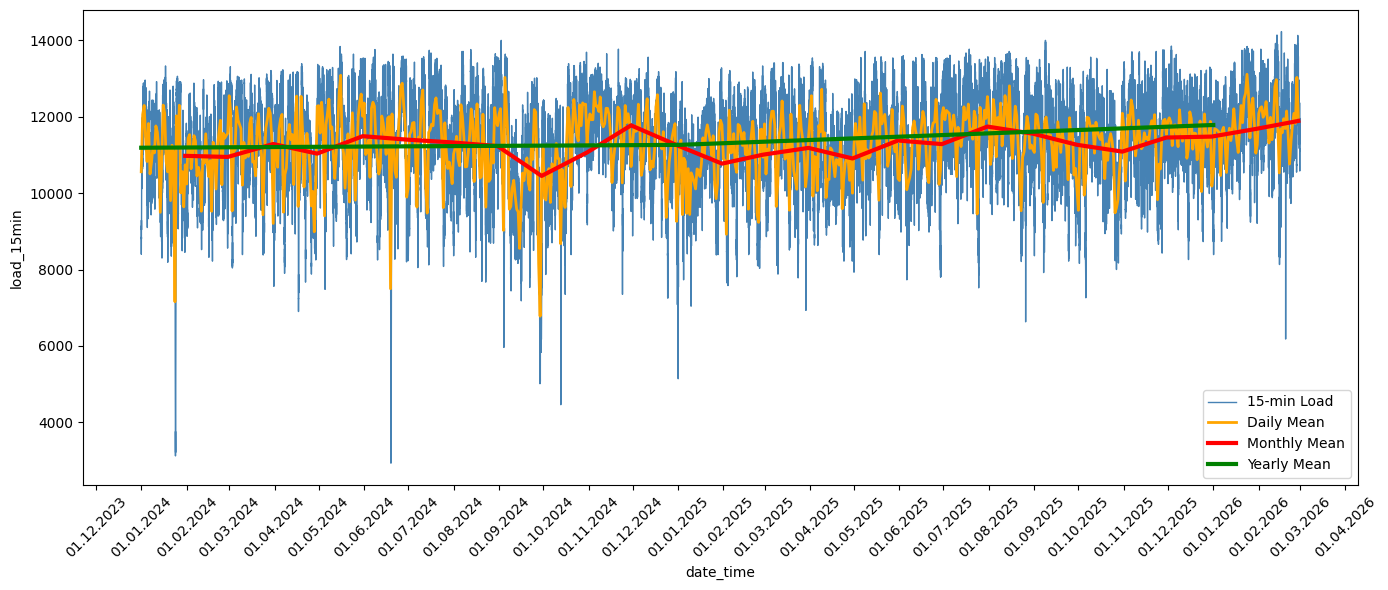

In [147]:
start_date = "2024"     # only year "2024" -> a specific month "2024-1" -> a specific day "2024-1-30"
end_date = "2026"

# select time period
df_plot = df_clean.loc[start_date:end_date]

# calculate montly averages
df_monthly_average = df_plot["load_15min"].resample("ME").mean()   # D - daily average; ME -> monthly average (assign to the last day (E=end) of the month)
# calculate yearly averages
df_yearly_average = df_plot["load_15min"].resample("YS").mean()   # D - daily average; ME -> monthly average (assign to the last day (E=end) of the month)
# calculate yearly averages
df_daily_average = df_plot["load_15min"].resample("D").mean()   # D - daily average; ME -> monthly average (assign to the last day (E=end) of the month)


plt.figure(figsize=(14,6))

# main line (15-min values)
sns.lineplot(
    data=df_plot.reset_index(),
    x="date_time",
    y="load_15min",
    linewidth=1.0,
    color="steelblue",
    label="15-min Load"
)

# daily averages
sns.lineplot(
    x=df_daily_average.index,
    y=df_daily_average.values,
    linewidth=2.0,
    color="orange",
    label="Daily Mean"
)

# monthly averages
sns.lineplot(
    x=df_monthly_average.index,
    y=df_monthly_average.values,
    linewidth=3.0,
    color="red",
    label="Monthly Mean"
)

# yearly averages
sns.lineplot(
    x=df_yearly_average.index,
    y=df_yearly_average.values,
    linewidth=3.0,
    color="green",
    label="Yearly Mean"
)


# customized date axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))     # display only day point per month on x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xticks(rotation=45)
# plt.gcf().autofmt_xdate()         # automatically format and rotate the date

plt.tight_layout()
plt.legend()
plt.show()


### 4.3 - histplot -> load distribution 

<Axes: xlabel='load_15min', ylabel='Count'>

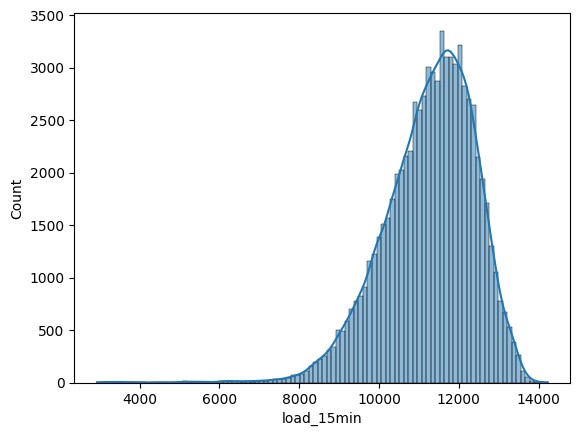

In [148]:
sns.histplot(x = df_clean["load_15min"], bins=100, kde=True)  

## 5. - feature engineering | weather

### 5.1 - wet bulb temperature

In [149]:
df_clean["wet_bulb"] = wet_bulb_temperature(
                                    df_clean["temp"],
                                    df_clean["rel_humidity"]
)

In [150]:
df_clean.isna().sum()

load_15min      0
temp            0
rel_humidity    0
wind            0
radiation       0
precip          0
clouds          0
wet_bulb        0
dtype: int64

### 5.2 - heating degree days (HDD) and cooling degree days (CDD) | daily and quarterly

In [151]:
df_clean

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb
date_time,,,,,,,,
2024-01-01 00:00:00,9130,3.50,94.00,31.400,0.0,0.000,100.0,2.86
2024-01-01 00:15:00,9050,3.50,93.75,31.650,0.0,0.025,94.5,2.84
2024-01-01 00:30:00,8960,3.50,93.50,31.900,0.0,0.050,89.0,2.82
2024-01-01 00:45:00,8950,3.50,93.25,32.150,0.0,0.075,83.5,2.80
2024-01-01 01:00:00,8610,3.50,93.00,32.400,0.0,0.100,78.0,2.78
...,...,...,...,...,...,...,...,...
2026-02-28 22:45:00,11000,2.45,93.75,12.375,0.0,0.000,1.5,1.80
2026-02-28 23:00:00,10940,2.30,94.00,12.100,0.0,0.000,2.0,1.67
2026-02-28 23:15:00,10580,2.30,94.00,12.100,0.0,0.000,2.0,1.67


In [152]:
df_clean.isna().sum()

load_15min      0
temp            0
rel_humidity    0
wind            0
radiation       0
precip          0
clouds          0
wet_bulb        0
dtype: int64

In [153]:

df_weather_15min["date"] = df_weather_15min.index.date          # create date column
daily_mean = df_weather_15min.groupby("date")["temp"].mean()    # group by date to calculate the mean temperature for each day

# calculate daily hdd and cdd
df_hdd = daily_mean.apply(lambda T: heating_degree_day(T, base=15)) # base -> existing buildings = 15°C; low-energy houses = 12°C; passive houses = 10°C
df_cdd = daily_mean.apply(lambda T: cooling_degree_day(T, base=22))

df_degree_days = pd.DataFrame({
    "date": df_hdd.index,
    "hdd_daily": df_hdd.values,
    "cdd_daily": df_cdd.values
}).set_index("date")

df_clean["date"] = df_clean.index.date

# Date as Key
df_clean = df_clean.join(
    df_degree_days,
    on="date"
)

# calculate quarterly hdd and cdd
df_clean["hdd_quarterly"] = df_clean["temp"].apply(lambda T: heating_degree_day(T, base=15))
df_clean["cdd_quarterly"] = df_clean["temp"].apply(lambda T: cooling_degree_day(T, base=22))

df_clean.head()


,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly
date_time,,,,,,,,,,,,,
2024-01-01 00:00:00,9130,3.5,94.00,31.40,0.0,0.000,100.0,2.86,2024-01-01,11.63,0.0,11.5,0.0
2024-01-01 00:15:00,9050,3.5,93.75,31.65,0.0,0.025,94.5,2.84,2024-01-01,11.63,0.0,11.5,0.0
2024-01-01 00:30:00,8960,3.5,93.50,31.90,0.0,0.050,89.0,2.82,2024-01-01,11.63,0.0,11.5,0.0
2024-01-01 00:45:00,8950,3.5,93.25,32.15,0.0,0.075,83.5,2.80,2024-01-01,11.63,0.0,11.5,0.0
2024-01-01 01:00:00,8610,3.5,93.00,32.40,0.0,0.100,78.0,2.78,2024-01-01,11.63,0.0,11.5,0.0


### 5.3 - check 

In [154]:
# check count of NaN values after filling the gaps
print(df_clean.isna().sum())

load_15min       0
temp             0
rel_humidity     0
wind             0
radiation        0
precip           0
clouds           0
wet_bulb         0
date             0
hdd_daily        0
cdd_daily        0
hdd_quarterly    0
cdd_quarterly    0
dtype: int64


## 6. - feature engineering | date/time
**change time to utc**                          ✅

**add columns:**
- split time/date                                 
    - hour (cyclical encoding)                  ✅
    - minute (cyclical encoding)                ✅
    - month (cyclical encoding)                 ✅
    - season (cyclical encoding)                ✅
- weekday (3 versions)
    - weekday (0 = monday ... 6 = sunday)       ✅
    - weekday (one hot encoding)                ✅
    - weekday (cyclical encoding)               ✅
- weekend (1/0)                                 ✅
- public holidays (1/0)                         ✅
- bridging day (1/0)                            ✅
- shifts
    - early shift (1/0)                         ✅
    - late shift (1/0)                          ✅
    - night shift (1/0)                         ✅
- shift change (13-15, 21-23, 5-7)
    - shift change early -> late (0/1 = 13-15)  ✅
    - shift change late -> night (0/1 = 21-23)  ✅
    - shift change night -> early (0/1 = 5-7)   ✅
- load x hours ago                              
    - load_1h_ago                               ✅
    - load_2h_ago                               ✅
    - load_24h_ago                              ✅
    - load_168h_ago                             ✅
- rolling mean -> last x hours
    - rolling_mean_3h                           ✅
    - rolling_mean_6h                           ✅
    - rolling_mean_12h                          ✅
- rolling std -> last x hours
    - rolling_std_3h                            ✅
    - rolling_std_6h                            ✅
    - rolling_std_12h                           ✅






### 6.1 - create colums for time/date (hours, minutes, month)
- ordinal -> better for tree based models
    - 0 - 23 -> hours
    - 0 - 59 -> minutes
    - 1 - 12 -> month
    - 1 - 4 -> season (1= winter ...)
- one hot encoding -> doesn't make sense, based on the number of values
- cyclical encoding -> best for timeseries data and forecasting
    - hour_sin
    - hour_cos
    - hour_sin
    - hour_cos
    - month_sin
    - month_cos
    - season_sin
    - season_cos
    - the model understands that midnight (0) is close to 11 p.m. (23) and also close to 1 a.m. (1)

In [155]:
# hour of the day (0 - 23)
df_clean["hour"] = df_clean.index.hour
# minute of the hour (0 - 59)
df_clean["minute"] = df_clean.index.minute
# time of day in minutes (0 - 1439)
df_clean["time"] = df_clean["hour"] * 60 + df_clean["minute"]
# month of the year (1 - 12)
df_clean["month"] = df_clean.index.month
# season (1=winter; ... ; 4=autumn)
df_clean["season"] = df_clean.index.month.map(get_season)
df_clean.head(22000)

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,hour,minute,time,month,season
date_time,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9130,3.50,94.00,31.40,0.0,0.000,100.0,2.86,2024-01-01,11.63,0.0,11.5,0.0,0,0,0,1,1
2024-01-01 00:15:00,9050,3.50,93.75,31.65,0.0,0.025,94.5,2.84,2024-01-01,11.63,0.0,11.5,0.0,0,15,15,1,1
2024-01-01 00:30:00,8960,3.50,93.50,31.90,0.0,0.050,89.0,2.82,2024-01-01,11.63,0.0,11.5,0.0,0,30,30,1,1
2024-01-01 00:45:00,8950,3.50,93.25,32.15,0.0,0.075,83.5,2.80,2024-01-01,11.63,0.0,11.5,0.0,0,45,45,1,1
2024-01-01 01:00:00,8610,3.50,93.00,32.40,0.0,0.100,78.0,2.78,2024-01-01,11.63,0.0,11.5,0.0,1,0,60,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-17 02:45:00,12240,16.80,96.50,12.00,0.0,0.000,100.0,16.38,2024-08-17,0.00,0.0,0.0,0.0,2,45,165,8,3
2024-08-17 03:00:00,12260,16.70,97.00,11.80,0.0,0.000,100.0,16.34,2024-08-17,0.00,0.0,0.0,0.0,3,0,180,8,3
2024-08-17 03:15:00,12200,16.65,97.25,12.00,0.0,0.000,100.0,16.31,2024-08-17,0.00,0.0,0.0,0.0,3,15,195,8,3


In [156]:
# hour of the day (0 - 23) -> transform to sine and cosine
df_clean = encode_cyclic(df_clean,"hour", 24)
# minute of the hours (0 - 59) -> transform to sine and cosine
df_clean = encode_cyclic(df_clean,"minute", 60)
# time of day in minutes (0 - 1439) -> transform to sine and cosine
df_clean = encode_cyclic(df_clean,"time", 24*60)
# month (1 - 12) -> transform to sine and cosine
df_clean = encode_cyclic(df_clean,"month", 24*60, offset=-1)
# season (1 - 4) -> transform to sine and cosine
df_clean = encode_cyclic(df_clean,"season", 4, offset=-1)

df_clean.head()

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9130,3.5,94.00,31.40,0.0,0.000,100.0,2.86,2024-01-01,11.63,0.0,11.5,0.0,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0
2024-01-01 00:15:00,9050,3.5,93.75,31.65,0.0,0.025,94.5,2.84,2024-01-01,11.63,0.0,11.5,0.0,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0
2024-01-01 00:30:00,8960,3.5,93.50,31.90,0.0,0.050,89.0,2.82,2024-01-01,11.63,0.0,11.5,0.0,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0
2024-01-01 00:45:00,8950,3.5,93.25,32.15,0.0,0.075,83.5,2.80,2024-01-01,11.63,0.0,11.5,0.0,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0
2024-01-01 01:00:00,8610,3.5,93.00,32.40,0.0,0.100,78.0,2.78,2024-01-01,11.63,0.0,11.5,0.0,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0


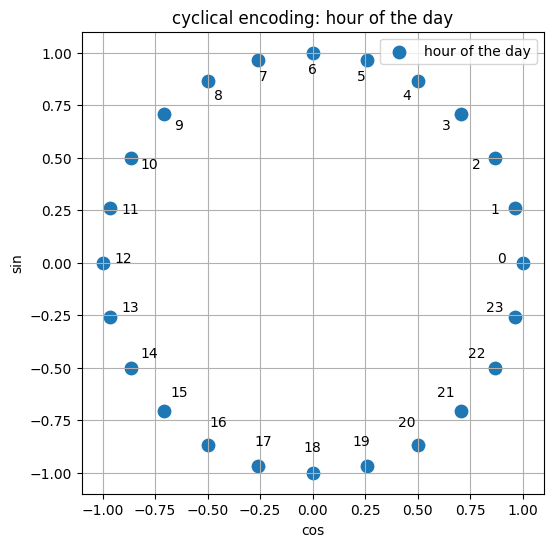

In [157]:
count = 24

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='hour of the day')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding: hour of the day")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

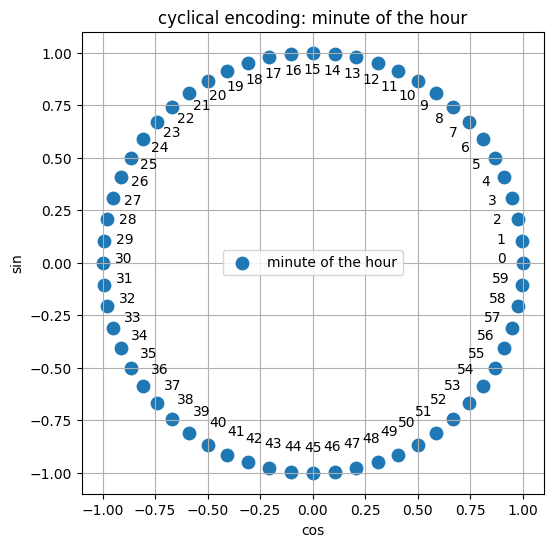

In [158]:
count = 60

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='minute of the hour')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding: minute of the hour")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

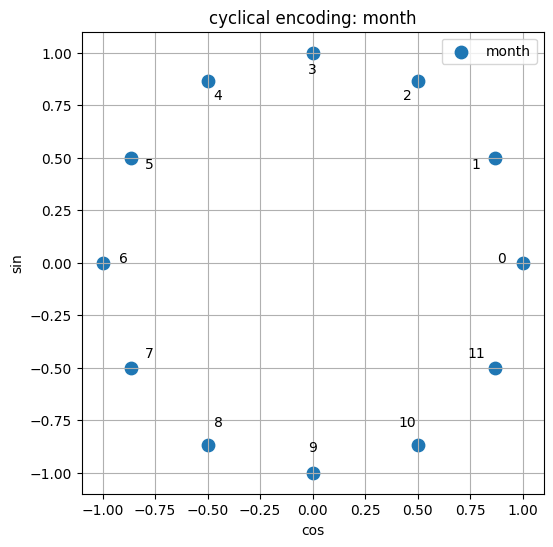

In [159]:
count = 12

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='month')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding: month")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

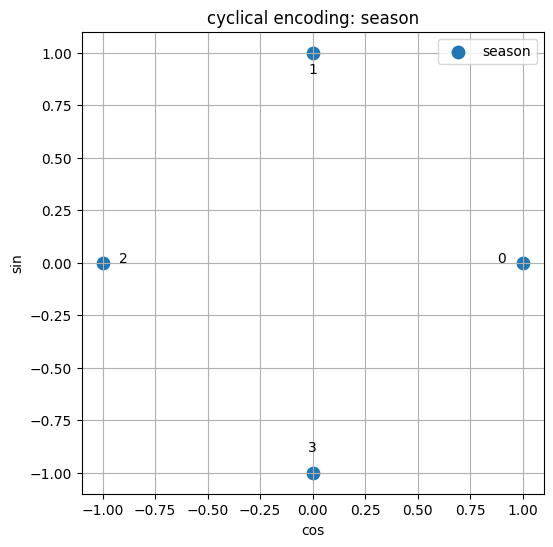

In [160]:
count = 4

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='season')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding: season")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

### 6.2 - create columns for the weekdays
- ordinal -> better for tree based models
    - 0 -> monday
    - 1 -> tuesday
    - 2 -> wednesday
    - 3 -> thursday
    - 4 -> friday
    - 5 -> saturday
    - 6 -> sunday
- one hot encoding -> better for linear models
    - monday (0/1)
    - tuesday (0/1)
    - ...
- cyclical encoding -> best for timeseries data and forecasting
    - weekday_sin
    - weekday_cos
    - the model understands that monday (0) is close to sunday (6)

#### 6.2.1 - weekday (ordinal)

In [161]:
# weekday (monday=0 ... sunday=6)
df_clean["weekday"] = df_clean.index.dayofweek
print(df_clean["weekday"].value_counts())

weekday
0    10848
1    10848
2    10848
3    10848
4    10848
5    10848
6    10752
Name: count, dtype: int64


**96 sundays "missing"** -> let's check this

In [162]:
print(f"first weekday of dataset: {df_clean["weekday"].iloc[0]}")
print(f"last weekday of dataset: {df_clean["weekday"].iloc[-1]}")

first weekday of dataset: 0
last weekday of dataset: 5


**because we have one value each 15 minutes (4 values/hour) and there is one sunday less than all other weekdays**
- 4 values/h * 24 h = 96 values -> **96 values/day**

#### 6.2.2 - weekday (one hot encoding)

In [163]:
dummies = pd.get_dummies(df_clean["weekday"], prefix="weekday")   # I don't want to drop the old column "weekend"
df_clean = pd.concat([df_clean, dummies], axis=1)
df_clean.head()

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9130,3.5,94.00,31.40,0.0,0.000,100.0,2.86,2024-01-01,11.63,0.0,11.5,0.0,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False
2024-01-01 00:15:00,9050,3.5,93.75,31.65,0.0,0.025,94.5,2.84,2024-01-01,11.63,0.0,11.5,0.0,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False
2024-01-01 00:30:00,8960,3.5,93.50,31.90,0.0,0.050,89.0,2.82,2024-01-01,11.63,0.0,11.5,0.0,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False
2024-01-01 00:45:00,8950,3.5,93.25,32.15,0.0,0.075,83.5,2.80,2024-01-01,11.63,0.0,11.5,0.0,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False
2024-01-01 01:00:00,8610,3.5,93.00,32.40,0.0,0.100,78.0,2.78,2024-01-01,11.63,0.0,11.5,0.0,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False


#### 6.2.3 - weekday (cyclical encoding)
- based on the fact that the week is a loop
    - after sunday comes monday again, it is like a circle.

**Therefore, I can represent it with sine and cosine.**


In [164]:
df_clean = encode_cyclic(df_clean, "weekday", 7)

df_clean.head()

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9130,3.5,94.00,31.40,0.0,0.000,100.0,2.86,2024-01-01,11.63,0.0,11.5,0.0,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0
2024-01-01 00:15:00,9050,3.5,93.75,31.65,0.0,0.025,94.5,2.84,2024-01-01,11.63,0.0,11.5,0.0,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0
2024-01-01 00:30:00,8960,3.5,93.50,31.90,0.0,0.050,89.0,2.82,2024-01-01,11.63,0.0,11.5,0.0,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0
2024-01-01 00:45:00,8950,3.5,93.25,32.15,0.0,0.075,83.5,2.80,2024-01-01,11.63,0.0,11.5,0.0,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0
2024-01-01 01:00:00,8610,3.5,93.00,32.40,0.0,0.100,78.0,2.78,2024-01-01,11.63,0.0,11.5,0.0,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0


**show distribution of weekdays on the circle**

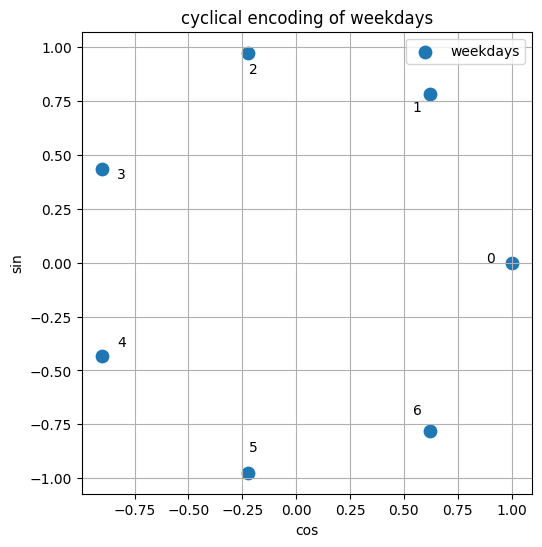

In [165]:
count = 7

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='weekdays')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding of weekdays")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

### 6.3 - create column weekend/bridging day
- weekend 
    - 0 -> it's not the weekend (monday to friday)
    - 1 -> it's the weekend (saturday + sunday)
- bridging day
    - 0 -> no
    - 1 -> yes -> if thursday is holiday, then friday is a bridging day (tuesday holiday -> monday bridging day)

In [166]:
df_clean["weekend"] = 0
df_clean.loc[(df_clean["weekday"] >= 5), "weekend"] = 1
df_clean.head(-5)
df_clean["weekend"].value_counts()

weekend
0    54240
1    21600
Name: count, dtype: int64

Let's check if ->  **saturdays + sundays = weekend days**

In [167]:
weekend_days = df_clean["weekend"][df_clean["weekend"] == 1].count()
sat_sun_days = df_clean["weekday"][(df_clean["weekday"] >= 5)].count()

print(f"weekend days in dataset: {weekend_days}")
print(f"saturdays/sundays in dataset: {sat_sun_days}")
print(weekend_days==sat_sun_days)

weekend days in dataset: 21600
saturdays/sundays in dataset: 21600
True


### 6.4 - create shifts (early, late, night and shift change)
- early shift -> 6 a.m. to 2 p.m
- late shift -> 2 p.m. to 10 p.m
- early shift -> 10 p.m. to 6 a.m.


In [168]:
df_clean["early_shift"] = 0
df_clean["late_shift"] = 0
df_clean["night_shift"] = 0
df_clean.loc[(df_clean.index.hour >= 6) & (df_clean.index.hour < 14),"early_shift"] = 1
df_clean.loc[(df_clean.index.hour >= 14) & (df_clean.index.hour < 22),"late_shift"] = 1
df_clean.loc[(df_clean.index.hour >= 22) | (df_clean.index.hour < 6),"night_shift"] = 1
df_clean.head()

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9130,3.5,94.00,31.40,0.0,0.000,100.0,2.86,2024-01-01,11.63,0.0,11.5,0.0,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1
2024-01-01 00:15:00,9050,3.5,93.75,31.65,0.0,0.025,94.5,2.84,2024-01-01,11.63,0.0,11.5,0.0,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1
2024-01-01 00:30:00,8960,3.5,93.50,31.90,0.0,0.050,89.0,2.82,2024-01-01,11.63,0.0,11.5,0.0,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1
2024-01-01 00:45:00,8950,3.5,93.25,32.15,0.0,0.075,83.5,2.80,2024-01-01,11.63,0.0,11.5,0.0,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1
2024-01-01 01:00:00,8610,3.5,93.00,32.40,0.0,0.100,78.0,2.78,2024-01-01,11.63,0.0,11.5,0.0,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1


In [169]:
time_sc_el = 14     # time when shift changes from early shift to late shift
time_sc_ln = 22     # time when shift changes from late shift to night shift
time_sc_ln = 6      # time when shift changes from night shift to early shift
time_sc_diff = 1    # 1h -> do not change!!!

shiftchange_el = (df_clean.index.hour >= time_sc_el - time_sc_diff) & (df_clean.index.hour < time_sc_el + time_sc_diff)
shiftchange_ln = (df_clean.index.hour >= time_sc_ln - time_sc_diff) & (df_clean.index.hour < time_sc_ln + time_sc_diff)
shiftchange_ne = (df_clean.index.hour >= time_sc_ln - time_sc_diff) & (df_clean.index.hour < time_sc_ln + time_sc_diff)

df_clean["shiftchange_el"] = 0
df_clean["shiftchange_ln"] = 0
df_clean["shiftchange_ne"] = 0


df_clean.loc[shiftchange_el,"shiftchange_el"] = 1
df_clean.loc[shiftchange_ln,"shiftchange_ln"] = 1
df_clean.loc[shiftchange_ne,"shiftchange_ne"] = 1
df_clean.head()

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9130,3.5,94.00,31.40,0.0,0.000,100.0,2.86,2024-01-01,11.63,0.0,11.5,0.0,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0
2024-01-01 00:15:00,9050,3.5,93.75,31.65,0.0,0.025,94.5,2.84,2024-01-01,11.63,0.0,11.5,0.0,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0
2024-01-01 00:30:00,8960,3.5,93.50,31.90,0.0,0.050,89.0,2.82,2024-01-01,11.63,0.0,11.5,0.0,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0
2024-01-01 00:45:00,8950,3.5,93.25,32.15,0.0,0.075,83.5,2.80,2024-01-01,11.63,0.0,11.5,0.0,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0
2024-01-01 01:00:00,8610,3.5,93.00,32.40,0.0,0.100,78.0,2.78,2024-01-01,11.63,0.0,11.5,0.0,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0


### 6.5 - create column holiday/bridging day

In [170]:
# e. g. german holidays for Rhineland-Palatinate
var_holidays = holidays.Germany(years=df_clean.index.year.unique(), prov="RP")

# creat column: 1 = holiday, 0 = normal day
df_clean["date"] = df_clean.index.date    # extract date to compare with the date of the holidays list
df_clean["holiday"] = df_clean["date"].isin(var_holidays).astype(int)

In [171]:
# creat column: 1 = bridging day, 0 = not a bridging day
holiday_dates = list(var_holidays.keys())  # datetime.date Objekte

bridge_days = set()

for h in holiday_dates:
    # day before the holiday (only if holiday is on tuesday -> the day before is monday)
    prev_day = h - dt.timedelta(days=1)     # subtract one day from the holiday date
    if prev_day.weekday() == 0:  # 0 = monday
        bridge_days.add(prev_day)

    # day after the holiday (only if holiday is on thursday -> the day after is friday)
    next_day = h + dt.timedelta(days=1)     # add one day to the holiday date
    if next_day.weekday() == 4:  # 4 = friday
        bridge_days.add(next_day)

bridge_days = sorted(list(bridge_days))


df_clean["bridging_day"] = (df_clean["date"].isin(bridge_days)).astype(int)

In [172]:
# print holidays in a specified year (only if they exist in the dataset)
year = 2024

holiday_dates_year = (
    df_clean
        .loc[
            (df_clean["holiday"] == 1) &
            (df_clean.index.year == year)
        ]
        .index
        .date
)

# Duplikate entfernen (weil 15-Minuten-Auflösung)
holiday_dates_year_unique = sorted(list(set(holiday_dates_year)))

# Anzahl
count_of_holidays = len(holiday_dates_year_unique)

print(count_of_holidays)
display(holiday_dates_year_unique)


11


[datetime.date(2024, 1, 1),
 datetime.date(2024, 3, 29),
 datetime.date(2024, 4, 1),
 datetime.date(2024, 5, 1),
 datetime.date(2024, 5, 9),
 datetime.date(2024, 5, 20),
 datetime.date(2024, 5, 30),
 datetime.date(2024, 10, 3),
 datetime.date(2024, 11, 1),
 datetime.date(2024, 12, 25),
 datetime.date(2024, 12, 26)]

In [173]:
# print bridging days in a specified year (only if they exist in the dataset)
year = 2024

bringing_day_dates_year = (
    df_clean
        .loc[
            (df_clean["bridging_day"] == 1) &
            (df_clean.index.year == year)
        ]
        .index
        .date
)

# Duplikate entfernen (weil 15-Minuten-Auflösung)
bringing_day_dates_year_unique = sorted(list(set(bringing_day_dates_year)))

# Anzahl
count_of_bridging_days = len(bringing_day_dates_year_unique)

print(count_of_bridging_days)
display(bringing_day_dates_year_unique)

4


[datetime.date(2024, 5, 10),
 datetime.date(2024, 5, 31),
 datetime.date(2024, 10, 4),
 datetime.date(2024, 12, 27)]

## 7. - split into train, eval and test df and add rolling and laf features

### 7.1 - split into 3 sets

In [175]:
# train -> 2024
df_train = df_clean[df_clean.index.year == 2024]


# evaluation -> 2025
df_eval = df_clean[df_clean.index.year == 2025]


# test -> 2026 (only 2 months available)
df_test = df_clean[df_clean.index.year == 2026]


print(len(df_train), len(df_eval), len(df_test))

35136 35040 5664


### 7.2 - create rolling and lag features

In [177]:
df_train = add_features(df_train)
df_eval = add_features(df_eval)
df_test = add_features(df_test)

In [178]:
df_train

,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,holiday,bridging_day,load_15min_ago,load_30min_ago,load_1h_ago,load_2h_ago,load_4h_ago,load_6h_ago,load_12h_ago,load_24h_ago,load_168h_ago,rolling_mean_1h,rolling_mean_3h,rolling_mean_4h,rolling_mean_6h,rolling_mean_12h,rolling_mean_24h,rolling_std_3h,rolling_std_6h,rolling_std_12h,temp_lag1h,temp_lag3h,temp_lag6h,temp_lag24h,temp_lag48h,rolling_temp_3h,rolling_temp_6h,rolling_temp_12h,wet_bulb_lag1h,wet_bulb_lag3h,wet_bulb_lag6h,wet_bulb_lag24h,wet_bulb_lag48h,rolling_wet_bulb_3h,rolling_wet_bulb_6h,rolling_wet_bulb_12h,radiation_lag1h,radiation_lag3h,radiation_lag6h,radiation_lag24h,radiation_lag48h,rolling_radiation_3h,rolling_radiation_6h,rolling_radiation_12h,precip_lag1h,precip_lag3h,precip_lag6h,precip_lag24h,precip_lag48h,rolling_precip_3h,rolling_precip_6h,rolling_precip_12h,rel_humidity_lag1h,rel_humidity_lag3h,rel_humidity_lag6h,rel_humidity_lag24h,rel_humidity_lag48h,rolling_rel_humidity_3h,rolling_rel_humidity_6h,rolling_rel_humidity_12h,wind_lag1h,wind_lag3h,wind_lag6h,wind_lag24h,wind_lag48h,rolling_wind_3h,rolling_wind_6h,rolling_wind_12h,clouds_lag1h,clouds_lag3h,clouds_lag6h,clouds_lag24h,clouds_lag48h,rolling_clouds_3h,rolling_clouds_6h,rolling_clouds_12h
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9130,3.500,94.00,31.400,0.0,0.000,100.0,2.86,2024-01-01,11.63,0.0,11.50,0.0,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000,1.000000,0.0,1.0,0,True,False,False,False,False,False,False,0.000000,1.00000,0,0,0,1,0,0,0,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.500000,3.500000,3.500000,NaN,NaN,NaN,NaN,NaN,2.860000,2.860000,2.860000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,94.000000,94.000000,94.000000,NaN,NaN,NaN,NaN,NaN,31.400000,31.400000,31.400000,NaN,NaN,NaN,NaN,NaN,100.00,100.00,100.00
2024-01-01 00:15:00,9050,3.500,93.75,31.650,0.0,0.025,94.5,2.84,2024-01-01,11.63,0.0,11.50,0.0,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.000000,1.000000,0.0,1.0,0,True,False,False,False,False,False,False,0.000000,1.00000,0,0,0,1,0,0,0,1,0,9130,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.500000,3.500000,3.500000,NaN,NaN,NaN,NaN,NaN,2.850000,2.850000,2.850000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,0.0125,0.0125,0.0125,NaN,NaN,NaN,NaN,NaN,93.875000,93.875000,93.875000,NaN,NaN,NaN,NaN,NaN,31.525000,31.525000,31.525000,NaN,NaN,NaN,NaN,NaN,97.25,97.25,97.25
2024-01-01 00:30:00,8960,3.500,93.50,31.900,0.0,0.050,89.0,2.82,2024-01-01,11.63,0.0,11.50,0.0,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.000000,1.000000,0.0,1.0,0,True,False,False,False,False,False,False,0.000000,1.00000,0,0,0,1,0,0,0,1,0,9050,9130,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.500000,3.500000,3.500000,NaN,NaN,NaN,NaN,NaN,2.840000,2.840000,2.840000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,0.0250,0.0250,0.0250,NaN,NaN,NaN,NaN,NaN,93.750000,93.750000,93.750000,NaN,NaN,NaN,NaN,NaN,31.650000,31.650000,31.650000,NaN,NaN,NaN,NaN,NaN,94.50,94.50,94.50
2024-01-01 00:45:00,8950,3.500,93.25,32.150,0.0,0.075,83.5,2.80,2024-01-01,11.63,0.0,11.50,0.0,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.000000,1.000000,0.0,1.0,0,True,False,False,False,False,False,False,

### 7.3 - delete NaN rows -> for the first rows there is no historical data

**based on the "load_168h_ago", we will lose 168*4=672 rows from the beginning of the dataset**

In [180]:
print(df_train.isna().sum()[df_train.isna().sum() > 0])
print(df_eval.isna().sum()[df_eval.isna().sum() > 0])
print(df_test.isna().sum()[df_test.isna().sum() > 0])

load_15min_ago           1
load_30min_ago           2
load_1h_ago              4
load_2h_ago              8
load_4h_ago             16
load_6h_ago             24
load_12h_ago            48
load_24h_ago            96
load_168h_ago          672
rolling_mean_1h          3
rolling_mean_3h         11
rolling_mean_4h         15
rolling_mean_6h         23
rolling_mean_12h        47
rolling_mean_24h        95
rolling_std_3h          11
rolling_std_6h          23
rolling_std_12h         47
temp_lag1h               4
temp_lag3h              12
temp_lag6h              24
temp_lag24h             96
temp_lag48h            192
wet_bulb_lag1h           4
wet_bulb_lag3h          12
wet_bulb_lag6h          24
wet_bulb_lag24h         96
wet_bulb_lag48h        192
radiation_lag1h          4
radiation_lag3h         12
radiation_lag6h         24
radiation_lag24h        96
radiation_lag48h       192
precip_lag1h             4
precip_lag3h            12
precip_lag6h            24
precip_lag24h           96
p

In [ ]:
# here are no historical values for the first lines -> delete NaN rows -> only in this column
df_train = df_train.dropna(subset=["load_168h_ago"])
df_train.isna().sum()[df_train.isna().sum() > 0]

Series([], dtype: int64)

In [ ]:
# here are no historical values for the first lines -> delete NaN rows -> only in this column
df_eval = df_eval.dropna(subset=["load_168h_ago"])
df_eval.isna().sum()[df_eval.isna().sum() > 0]

Series([], dtype: int64)

In [ ]:
# here are no historical values for the first lines -> delete NaN rows -> only in this column
df_test = df_test.dropna(subset=["load_168h_ago"])
df_test.isna().sum()[df_test.isna().sum() > 0]

Series([], dtype: int64)

## 8. - save the final DataFrames as CSV

In [185]:
df_train.to_csv(r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_train.csv", index=True)

df_eval.to_csv(r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_eval.csv", index=True)

df_test.to_csv(r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_test.csv", index=True)

